# Анализ изменения выручки после внедрения ERP-системы

## Цель исследования

Определить, произошло ли увеличение выручки компании после внедрения ERP-системы.

Для анализа используются данные о выручке за пять одинаковых месяцев 2023 и 2024 годов. Предполагается, что ERP-система была внедрена в 2024 году.

Дополнительно проводится анализ с учётом инфляции на основе официальных данных Росстата, чтобы определить изменение выручки в сопоставимых ценах.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
data = {
    'Месяц': ['Январь', 'Февраль', 'Март', 'Апрель', 'Май'],
    '2023': [120, 165, 140, 150, 130],
    '2024': [145, 155, 140, 160, 150]
}

df = pd.DataFrame(data)

df

,Месяц,2023,2024
0,Январь,120,145
1,Февраль,165,155
2,Март,140,140
3,Апрель,150,160
4,Май,130,150


## 1. Первичный анализ данных

На первом этапе сравнивается выручка компании по каждому из пяти месяцев.

Для каждого месяца определяется абсолютное изменение выручки:

**Абсолютное изменение = Выручка 2024 − Выручка 2023**

Также рассчитывается относительное изменение выручки в процентах.

In [4]:
df['Изменение'] = df['2024'] - df['2023']

df['Изменение, %'] = (
    df['Изменение'] / df['2023'] * 100
)

df

,Месяц,2023,2024,Изменение,"Изменение, %"
0,Январь,120,145,25,20.833333
1,Февраль,165,155,-10,-6.060606
2,Март,140,140,0,0.000000
3,Апрель,150,160,10,6.666667
4,Май,130,150,20,15.384615


In [5]:
mean_2023 = df['2023'].mean()
mean_2024 = df['2024'].mean()

print(f'Средняя выручка в 2023 году: {mean_2023:.2f}')
print(f'Средняя выручка в 2024 году: {mean_2024:.2f}')

Средняя выручка в 2023 году: 141.00
Средняя выручка в 2024 году: 150.00


In [6]:
growth = mean_2024 / mean_2023 * 100
increase = (mean_2024 - mean_2023) / mean_2023 * 100

print(f"Темп роста: {growth:.2f}%")
print(f"Темп прироста: {increase:.2f}%")

Темп роста: 106.38%
Темп прироста: 6.38%


## 2. Визуальный анализ

Для наглядного сравнения строятся два графика:

1. сравнение средней выручки за два года;
2. сравнение выручки по каждому месяцу.

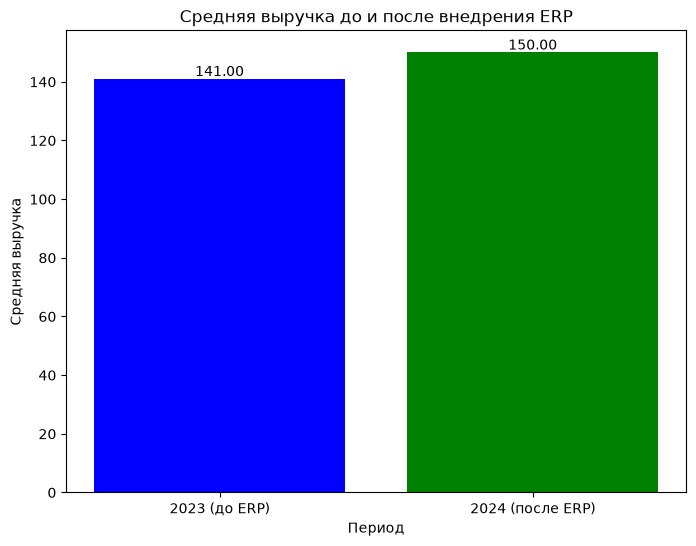

In [7]:
years = ['2023 (до ERP)', '2024 (после ERP)']
average_revenue = [mean_2023, mean_2024]

plt.figure(figsize=(8, 6))

plt.bar(
    years,
    average_revenue,
    color=['blue', 'green']
)

plt.title('Средняя выручка до и после внедрения ERP')
plt.ylabel('Средняя выручка')
plt.xlabel('Период')

for i, value in enumerate(average_revenue):
    plt.text(
        i,
        value + 1,
        f'{value:.2f}',
        ha='center'
    )

plt.show()

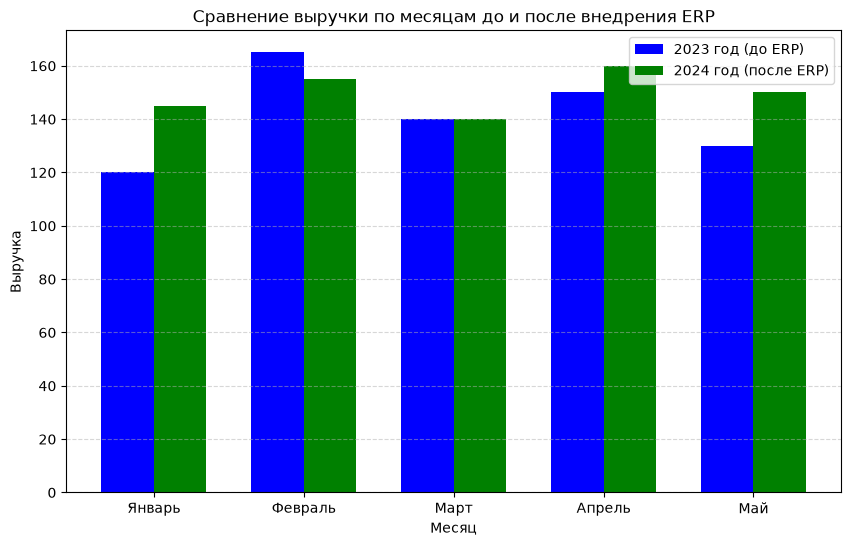

In [8]:
months = df['Месяц']

x = np.arange(len(months))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    df['2023'],
    width,
    color='blue',
    label='2023 год (до ERP)'
)

plt.bar(
    x + width / 2,
    df['2024'],
    width,
    color='green',
    label='2024 год (после ERP)'
)

plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.title('Сравнение выручки по месяцам до и после внедрения ERP')

plt.xticks(x, months)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## 3. Проверка статистической значимости изменения выручки

Для проверки того, является ли изменение выручки статистически значимым, применяется парный критерий Стьюдента.

Парный критерий используется потому, что сравниваются одинаковые месяцы двух лет: январь 2023 года с январём 2024 года, февраль с февралем и т.д.

### Гипотезы

**H₀:** среднее изменение выручки между 2023 и 2024 годами равно нулю.

**H₁:** среднее изменение выручки между 2023 и 2024 годами отличается от нуля.

Уровень значимости:

**α = 0,05.**

In [9]:
t_stat, p_value = stats.ttest_rel(
    df['2024'],
    df['2023']
)

print(f't = {t_stat:.3f}')
print(f'p-value = {p_value:.3f}')

t = 1.406
p-value = 0.233


Получено значение t = 1,406 и p-value = 0,233.

Так как p-value > 0,05, нулевая гипотеза не отвергается.

Следовательно, при имеющемся объёме данных статистически значимое изменение средней выручки между 2023 и 2024 годами не подтверждено.

При этом среднее значение выручки в 2024 году номинально выше, чем в 2023 году.

## 4. Анализ выручки с учётом инфляции

Номинальное увеличение выручки не всегда означает реальный рост экономического показателя, поскольку изменение выручки может быть связано с общим повышением уровня цен.

Для исключения влияния инфляции в анализ включаются официальные индексы потребительских цен Росстата.

В качестве периода сравнения принимаются январь–май 2024 года и соответствующие месяцы 2023 года.

Для пересчёта номинальной выручки 2024 года в цены 2023 года используется формула:

**Реальная выручка 2024 = Номинальная выручка 2024 / (ИПЦ / 100)**

Такой пересчёт позволяет получить приблизительную оценку выручки 2024 года в сопоставимых с 2023 годом ценах.

In [10]:
inflation_index = [107.40, 107.69, 107.72, 107.84, 108.30]

df['ИПЦ, %'] = inflation_index

df

,Месяц,2023,2024,Изменение,"Изменение, %","ИПЦ, %"
0,Январь,120,145,25,20.833333,107.40
1,Февраль,165,155,-10,-6.060606,107.69
2,Март,140,140,0,0.000000,107.72
3,Апрель,150,160,10,6.666667,107.84
4,Май,130,150,20,15.384615,108.30


In [11]:
df['2024 с учётом инфляции'] = (
    df['2024'] / (df['ИПЦ, %'] / 100)
)

df

,Месяц,2023,2024,Изменение,"Изменение, %","ИПЦ, %",2024 с учётом инфляции
0,Январь,120,145,25,20.833333,107.40,135.009311
1,Февраль,165,155,-10,-6.060606,107.69,143.931656
2,Март,140,140,0,0.000000,107.72,129.966580
3,Апрель,150,160,10,6.666667,107.84,148.367953
4,Май,130,150,20,15.384615,108.30,138.504155


In [12]:
mean_2024_real = df['2024 с учётом инфляции'].mean()

real_change = (
    (mean_2024_real - mean_2023)
    / mean_2023
    * 100
)

print(f'Средняя выручка 2023 года: {mean_2023:.2f}')
print(f'Средняя номинальная выручка 2024 года: {mean_2024:.2f}')
print(f'Средняя реальная выручка 2024 года: {mean_2024_real:.2f}')
print(f'Реальное изменение выручки: {real_change:.2f}%')

Средняя выручка 2023 года: 141.00
Средняя номинальная выручка 2024 года: 150.00
Средняя реальная выручка 2024 года: 139.16
Реальное изменение выручки: -1.31%


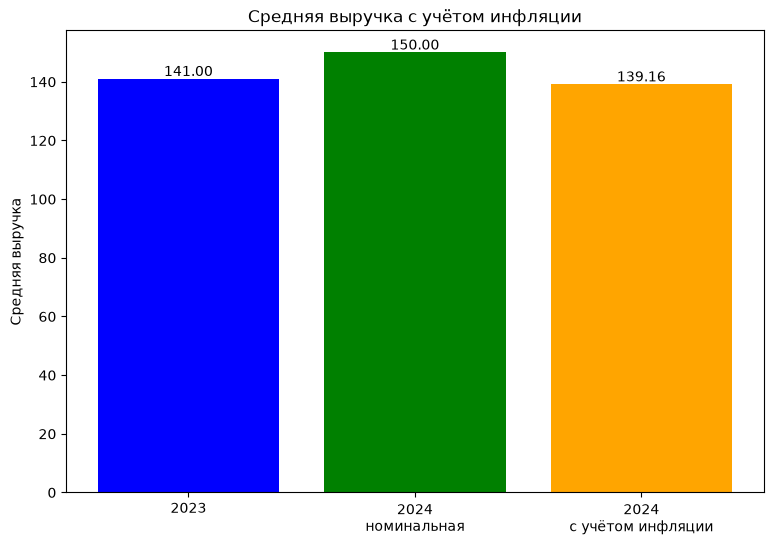

In [13]:
categories = [
    '2023',
    '2024\nноминальная',
    '2024\nс учётом инфляции'
]

values = [
    mean_2023,
    mean_2024,
    mean_2024_real
]

plt.figure(figsize=(9, 6))

plt.bar(
    categories,
    values,
    color=['blue', 'green', 'orange']
)

plt.title('Средняя выручка с учётом инфляции')
plt.ylabel('Средняя выручка')

for i, value in enumerate(values):
    plt.text(
        i,
        value + 1,
        f'{value:.2f}',
        ha='center'
    )

plt.show()

## 5. Статистическая проверка изменения выручки с учётом инфляции

После пересчёта выручки 2024 года в сопоставимые цены 2023 года повторно применяется парный критерий Стьюдента.

Нулевая гипотеза H₀: среднее изменение реальной выручки равно нулю.

Альтернативная гипотеза H₁: среднее изменение реальной выручки отличается от нуля.

Уровень значимости α = 0,05.

In [14]:
t_real, p_real = stats.ttest_rel(
    df['2024 с учётом инфляции'],
    df['2023']
)

print(f't = {t_real:.3f}')
print(f'p-value = {p_real:.3f}')

t = -0.287
p-value = 0.789


Получено значение t = -0,287 и p-value = 0,789.

Так как p-value > 0,05, нулевая гипотеза не отвергается.

Следовательно, статистически значимое изменение реальной выручки после учёта инфляции также не подтверждено.

При этом средняя реальная выручка снизилась с 141,00 до 139,16, то есть примерно на 1,31%.

## 6. Проверка распределения изменений с помощью критерия χ²

Для дополнительного анализа месячная динамика выручки разделяется на три категории:

- рост выручки;
- снижение выручки;
- отсутствие изменения.

С помощью критерия χ² проверяется соответствие наблюдаемого распределения равномерному распределению по трём категориям.

### Гипотезы

**H₀:** наблюдаемое распределение изменений соответствует равномерному распределению между тремя категориями.

**H₁:** наблюдаемое распределение отличается от равномерного.

Уровень значимости α = 0,05.

In [15]:
growth_categories = [
    'Рост',
    'Снижение',
    'Без изменений'
]

observed = [
    (df['Изменение'] > 0).sum(),
    (df['Изменение'] < 0).sum(),
    (df['Изменение'] == 0).sum()
]

chi2_stat, chi2_p = stats.chisquare(observed)

print('Наблюдаемые частоты:')
for category, value in zip(growth_categories, observed):
    print(f'{category}: {value}')

print(f'\nχ² = {chi2_stat:.3f}')
print(f'p-value = {chi2_p:.3f}')

Наблюдаемые частоты:
Рост: 3
Снижение: 1
Без изменений: 1

χ² = 1.600
p-value = 0.449


Получено значение χ² = 1,600 и p-value = 0,449.

Так как p-value > 0,05, нулевая гипотеза не отвергается.

Следовательно, при имеющемся объёме наблюдений статистически значимого отличия наблюдаемого распределения изменений от равномерного не выявлено.

Критерий χ² используется в работе как дополнительный метод анализа, поскольку исходные данные представляют собой количественные значения выручки.

In [16]:
summary = pd.DataFrame({
    'Показатель': [
        'Средняя выручка 2023',
        'Средняя выручка 2024, номинальная',
        'Темп роста',
        'Темп прироста',
        'Средняя выручка 2024, с учётом инфляции',
        'Реальное изменение выручки',
        't-критерий (номинальная выручка)',
        'p-value (номинальная выручка)',
        't-критерий (с учётом инфляции)',
        'p-value (с учётом инфляции)',
        'χ²',
        'p-value χ²'
    ],
    'Значение': [
        mean_2023,
        mean_2024,
        growth,
        increase,
        mean_2024_real,
        real_change,
        t_stat,
        p_value,
        t_real,
        p_real,
        chi2_stat,
        chi2_p
    ]
})

summary

,Показатель,Значение
0,Средняя выручка 2023,141.000000
1,"Средняя выручка 2024, номинальная",150.000000
2,Темп роста,106.382979
3,Темп прироста,6.382979
4,"Средняя выручка 2024, с учётом инфляции",139.155931
5,Реальное изменение выручки,-1.307850
6,t-критерий (номинальная выручка),1.405564
7,p-value (номинальная выручка),0.232566
8,t-критерий (с учётом инфляции),-0.286634
9,p-value (с учётом инфляции),0.788626


# Итоговый вывод

В ходе исследования была проанализирована выручка компании за пять одинаковых месяцев 2023 и 2024 годов. Предполагалось, что ERP-система была внедрена в 2024 году.

Первичный анализ показал увеличение средней номинальной выручки с 141,00 в 2023 году до 150,00 в 2024 году. Таким образом, средняя выручка увеличилась на 9 единиц, а темп прироста составил 6,38%.

Анализ помесячной динамики показал неоднородный характер изменений: в январе, апреле и мае наблюдался рост выручки, в феврале — снижение, а в марте значение осталось неизменным.

Для проверки статистической значимости изменения был применён парный критерий Стьюдента. Получено значение t = 1,406 и p-value = 0,233. При уровне значимости α = 0,05 статистически значимое изменение выручки не подтверждено.

Дополнительно был проведён анализ с учётом инфляции. Для этого использованы официальные индексы потребительских цен Росстата за январь–май 2024 года по отношению к соответствующим месяцам 2023 года. Номинальная выручка 2024 года была пересчитана в сопоставимые цены 2023 года.

После учёта инфляции средняя выручка 2024 года составила 139,16, что на 1,31% ниже средней выручки 2023 года. Таким образом, первоначальный номинальный рост выручки на 6,38% не сохраняется при пересчёте в сопоставимые цены.

Парный критерий Стьюдента для выручки с учётом инфляции дал значение t = -0,287 и p-value = 0,789. Следовательно, статистически значимого изменения реальной выручки также не выявлено.

Дополнительная проверка с использованием критерия χ² дала значение χ² = 1,600 и p-value = 0,449. Статистически значимого отличия наблюдаемого распределения изменений от равномерного также не обнаружено.

Таким образом, на основании пяти наблюдений нельзя сделать статистически обоснованный вывод о том, что внедрение ERP-системы привело к увеличению выручки компании. Номинально выручка выросла на 6,38%, однако после учёта инфляции наблюдается снижение средней реальной выручки примерно на 1,31%.

Для более надёжной оценки влияния ERP-системы целесообразно использовать более длительный период наблюдений, а также учитывать дополнительные факторы, влияющие на выручку компании.